PROJET DE DEEP LEARNING

# ***Prédiction de la qualité de l’air***

importe les bibliotheque necessaires

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)


# **chargement et préparation des données du projet**


*   Importation du dataset
*   emplace les valeurs manquantes (NaN) par la moyenne de chaque colonne numérique.
*   Informations sur les données


In [ ]:
from google.colab import files
uploaded = files.upload()
print("\n Chargement des données")
df = pd.read_excel('Cleaned_NSUT.xlsx')
df = df.fillna(df.mean(numeric_only=True))

print(f"    {df.shape[0]} observations | {df.shape[1]} colonnes")
print(f"   Colonnes : {df.columns.tolist()}")
print(f"   AQI : min={df['AQI'].min():.0f} | max={df['AQI'].max():.0f} | moy={df['AQI'].mean():.1f}")  #AQI = Air Quality Index.

Saving Cleaned_NSUT.xlsx to Cleaned_NSUT.xlsx

 Chargement des données
    1461 observations | 12 colonnes
   Colonnes : ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
   AQI : min=35 | max=498 | moy=222.1


## **creation des nouvelles variables**

*   categorie selon les valeurs de l'AQI.
*   saison selon le mois.



In [ ]:
# Crée une fonction aqi_cat qui transforme une valeur aqi a une categorie
def aqi_cat(v):
    if v<=50:   return 'Bon'
    elif v<=100: return 'Modéré'
    elif v<=150: return 'Mauvais (sensibles)'
    elif v<=200: return 'Mauvais'
    elif v<=300: return 'Très mauvais'
    else:        return 'Dangereux'

df['AQI_Cat'] = df['AQI'].apply(aqi_cat)
df['Saison']  = df['Month'].apply(
    lambda m: 'Hiver' if m in [12,1,2] else
              'Printemps' if m in [3,4,5] else
              'Été' if m in [6,7,8] else 'Automne')

# Le Feature Engineering

transformer les données brutes en données plus utiles pour le modèle.

In [ ]:
print("\n Feature Engineering...")

#saison en fonction d'un nombre
df['Saison_num']      = df['Month'].apply(lambda m: 0 if m in [12,1,2] else 1 if m in [3,4,5] else 2 if m in [6,7,8] else 3)
#ratio PM2.5 / PM10
df['PM_Ratio']        = df['PM2.5'] / (df['PM10'] + 1e-8)
#Indice global de pollution
df['Indice_Pollution']= df['PM2.5']*0.4 + df['PM10']*0.3 + df['NO2']*0.15 + df['SO2']*0.1 + df['CO']*0.05
#Transformation logarithmique
df['Log_PM25']        = np.log1p(df['PM2.5'])
df['Log_PM10']        = np.log1p(df['PM10'])

FEATURES_MLP = ['PM2.5','PM10','NO2','SO2','CO','Ozone',
                 'Month','Saison_num','Days','Holidays_Count',
                 'PM_Ratio','Indice_Pollution','Log_PM25','Log_PM10']

FEATURES_LSTM = ['PM2.5','PM10','NO2','SO2','CO','Ozone']  # séquences brutes

TARGET = 'AQI'
print(f"   MLP  : {len(FEATURES_MLP)} features")
print(f"   LSTM : {len(FEATURES_LSTM)} features (séquences temporelles)")



 Feature Engineering...
   MLP  : 14 features
   LSTM : 6 features (séquences temporelles)



# **Préparation des données pour entraîner le modèle Multilayer Perceptron (MLP)**
*  sélection des données
*  normalisation
*  séparation train/validation/test


In [ ]:
print("\n Normalisation et découpage (MLP)...")

X_mlp = df[FEATURES_MLP].values.astype(np.float64)
y_mlp = df[TARGET].values.astype(np.float64).reshape(-1, 1)

scaler_X_mlp = StandardScaler()
scaler_y_mlp = StandardScaler()
X_mlp_sc     = scaler_X_mlp.fit_transform(X_mlp)
y_mlp_sc     = scaler_y_mlp.fit_transform(y_mlp)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_mlp_sc, y_mlp_sc, test_size=0.30, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp,    y_tmp,    test_size=0.50, random_state=42)

print(f"   Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}")



 Normalisation et découpage (MLP)...
   Train: 1022 | Val: 219 | Test: 220


# **Prépare les données pour le modèle Long Short-Term Memory (LSTM)**

*   utilise les jours précédents pour prédire l’AQI du jour suivant

- nomalistaion avec minmax.
- le modèle regarde 10 jours précédents pour prédire le jour suivant.

In [ ]:
print("\n Normalisation et séquences (LSTM)...")

data_lstm = df[FEATURES_LSTM + [TARGET]].values.astype(np.float64)
# Normalisateur MinMax
scaler_lstm = MinMaxScaler()
# transforme les données entre 0 et 1
data_lstm_sc = scaler_lstm.fit_transform(data_lstm)

SEQ_LEN = 10

#la fonction creer_sequences transforme les données normales en séquences temporelles.
def creer_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i+seq_len, :-1])   # récupère seq_len toutes les colonnes sauf AQI
        y.append(data[i+seq_len, -1])          # AQI du jour suivant
    return np.array(X), np.array(y)

X_lstm, y_lstm = creer_sequences(data_lstm_sc, SEQ_LEN)

# Découpage temporel
n      = len(X_lstm)
#calcule les limites 70% 85%
t1, t2 = int(0.70*n), int(0.85*n)

#Séparation chronologique
X_lstm_tr,  y_lstm_tr  = X_lstm[:t1],    y_lstm[:t1]  #entraînement.
X_lstm_val, y_lstm_val = X_lstm[t1:t2],  y_lstm[t1:t2]  #validation.
X_lstm_te,  y_lstm_te  = X_lstm[t2:],    y_lstm[t2:]   #validation.

print(f"   Train: {len(X_lstm_tr)} séquences | Val: {len(X_lstm_val)} | Test: {len(X_lstm_te)}")
print(f"   Forme d'une séquence : {X_lstm_tr[0].shape}  (10 jours × 6 polluants)")



 Normalisation et séquences (LSTM)...
   Train: 1015 séquences | Val: 218 | Test: 218
   Forme d'une séquence : (10, 6)  (10 jours × 6 polluants)


# **Implémente un modèle Multilayer Perceptron entièrement**

- Les neurones
- la propagation avant
- la rétropropagation
- l’optimisation Adam
- le dropout
- l’early stopping

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ─────────────────────────────
# Construction du modèle MLP
# ─────────────────────────────
mlp_model = Sequential([

    Dense(32,
          activation='relu',
          input_shape=(len(FEATURES_MLP),)),

    Dropout(0.05),

    Dense(16,
          activation='relu'),

    Dense(1)
])

# ─────────────────────────────
# Compilation
# ─────────────────────────────
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# ─────────────────────────────
# Résumé architecture
# ─────────────────────────────
mlp_model.summary()

# ─────────────────────────────
# Entraînement
# ─────────────────────────────
history_mlp = mlp_model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


  Modèle MLP Simple (14 → 32 → 16 → 1)

   Architecture : 14 → 32 → 16 → 1
   Paramètres   : 1,025

   Epochs max: 600 | Batch: 64 | Patience: 20
   Époque |   Train Loss |     Val Loss | Statut
   ───────────────────────────────────────────────────────
        1 |     1.261330 |     0.933426 | ✅
       50 |     0.145877 |     0.111015 | ✅
      100 |     0.120778 |     0.091004 | ⏳ 1/20
      150 |     0.108330 |     0.087161 | ✅
      200 |     0.093166 |     0.085837 | ⏳ 1/20
      250 |     0.097538 |     0.084588 | ⏳ 17/20
   Early stopping époque 253
   Terminé. Meilleure val_loss : 0.083714

   [Train] MAE=20.86 | RMSE=29.80 | R²=0.9187

   [Val] MAE=22.80 | RMSE=30.57 | R²=0.9232

   [Test] MAE=27.23 | RMSE=39.98 | R²=0.8575


# **Implémente un modèle Long Short-Term Memory**


In [ ]:
#architecteur lstm :
def construire_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(64, activation='tanh', input_shape=(seq_len, n_features), # couche LSTM avec 64 neurones et donc 64 cellules mémoire
             return_sequences=False),
        Dropout(0.10), #désactive aléatoirement 10% des neurones
        Dense(32, activation='relu'), #couhce fully de 32 neurones
        Dropout(0.05),  #désactive 5% des neurones
        Dense(1)
    ])
    #Compilation du modèle
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse',
                  metrics=['mae'])
    return model

#construire le modele
lstm_model = construire_lstm(SEQ_LEN, len(FEATURES_LSTM))
print("\n   Architecture LSTM :")
lstm_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,  #Arrêter automatiquement l’entraînement quand le modèle n’apprend plus.
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, #réduire le learning rate quand le modèle approche du minimum
                      patience=10, min_lr=1e-5, verbose=0)
]

print("\n   Entraînement LSTM ")
history_lstm = lstm_model.fit(
    X_lstm_tr, y_lstm_tr,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Évaluation LSTM
def evaluer_lstm(model, X, y_scaled, scaler, n_feat, nom=""):
    y_pred_s = model.predict(X, verbose=0)

    # Reconstruire pour inverse_transform (MinMaxScaler sur toutes les colonnes)
    dummy_pred = np.zeros((len(y_pred_s), n_feat + 1))
    dummy_pred[:, -1] = y_pred_s.flatten()
    dummy_true = np.zeros((len(y_scaled), n_feat + 1))
    dummy_true[:, -1] = y_scaled.flatten()

    y_pred = scaler.inverse_transform(dummy_pred)[:, -1]
    y_true = scaler.inverse_transform(dummy_true)[:, -1]

    r = dict(MAE=mean_absolute_error(y_true, y_pred),
             RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
             R2=r2_score(y_true, y_pred),
             y_true=y_true, y_pred=y_pred)
    if nom:
        print(f"   [{nom}] MAE={r['MAE']:.2f} | RMSE={r['RMSE']:.2f} | R²={r['R2']:.4f}")
    return r

print()
lstm_tr  = evaluer_lstm(lstm_model, X_lstm_tr,  y_lstm_tr,  scaler_lstm, len(FEATURES_LSTM), "Train")
lstm_val = evaluer_lstm(lstm_model, X_lstm_val, y_lstm_val, scaler_lstm, len(FEATURES_LSTM), "Val")
lstm_te  = evaluer_lstm(lstm_model, X_lstm_te,  y_lstm_te,  scaler_lstm, len(FEATURES_LSTM), "Test")



   Architecture LSTM :


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)


   Entraînement LSTM 
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0394 - mae: 0.1565 - val_loss: 0.0190 - val_mae: 0.1103 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 - mae: 0.1088 - val_loss: 0.0171 - val_mae: 0.0996 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0180 - mae: 0.1050 - val_loss: 0.0165 - val_mae: 0.0993 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0170 - mae: 0.1023 - val_loss: 0.0161 - val_mae: 0.0996 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0160 - mae: 0.0990 - val_loss: 0.0156 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0164 - mae: 0.0995 - val_loss: 0.0151 - val_mae: 0.0978 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0158 - mae: 0.0980 - val_loss: 0.0151 - val_mae: 0.0985 - learni

In [ ]:
print(f""" COMPARAISON MLP vs LSTM

  {'Modèle':<30} {'Train R²':>9} {'Val R²':>9} {'Test R²':>9} {'MAE':>8} {'RMSE':>8}
  {'─'*65}
  {'MLP (from scratch)':<30} {mlp_tr['R2']:>9.4f} {mlp_val['R2']:>9.4f} {mlp_te['R2']:>9.4f} {mlp_te['MAE']:>8.2f} {mlp_te['RMSE']:>8.2f}
  {'LSTM (TensorFlow)':<30} {lstm_tr['R2']:>9.4f} {lstm_val['R2']:>9.4f} {lstm_te['R2']:>9.4f} {lstm_te['MAE']:>8.2f} {lstm_te['RMSE']:>8.2f}
  {'─'*65}
""")

best = 'MLP' if mlp_te['R2'] >= lstm_te['R2'] else 'LSTM'
br   = mlp_te if best == 'MLP' else lstm_te
print(f"  Meilleur modèle : {best}  (R²={br['R2']:.4f}, MAE={br['MAE']:.2f})")


 COMPARAISON MLP vs LSTM

  Modèle                          Train R²    Val R²   Test R²      MAE     RMSE
  ─────────────────────────────────────────────────────────────────
  MLP (from scratch)                0.9187    0.9232    0.8575    27.23    39.98
  LSTM (TensorFlow)                 0.8036    0.6491    0.8836    29.70    38.57
  ─────────────────────────────────────────────────────────────────

  Meilleur modèle : LSTM  (R²=0.8836, MAE=29.70)


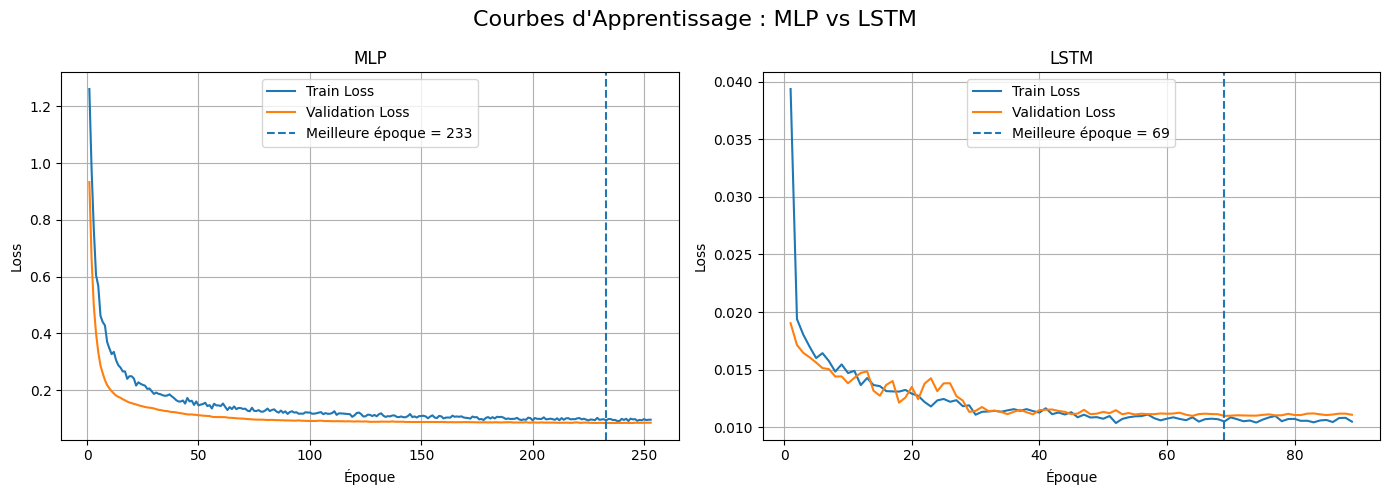

In [ ]:
#COURBES D'APPRENTISSAGE
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

plt.suptitle("Courbes d'Apprentissage : MLP vs LSTM", fontsize=16)

# MLP
ax = axes1[0]

ep1 = range(1, len(mlp.hist_tr)+1)

ax.plot(ep1, mlp.hist_tr, label='Train Loss')

ax.plot(ep1, mlp.hist_val,
        label='Validation Loss')

best_ep = mlp.hist_val.index(
    min(mlp.hist_val)
) + 1

ax.axvline(best_ep,
           linestyle='--',
           label=f'Meilleure époque = {best_ep}')

ax.set_title("MLP")

ax.set_xlabel("Époque")
ax.set_ylabel("Loss")

ax.legend()

ax.grid(True)

# LSTM
ax = axes1[1]

ep2 = range(
    1,
    len(history_lstm.history['loss']) + 1
)

ax.plot(ep2,
        history_lstm.history['loss'],
        label='Train Loss')

ax.plot(ep2,
        history_lstm.history['val_loss'],
        label='Validation Loss')

best_ep2 = history_lstm.history['val_loss'].index(
    min(history_lstm.history['val_loss'])
) + 1

ax.axvline(best_ep2,
           linestyle='--',
           label=f'Meilleure époque = {best_ep2}')

ax.set_title("LSTM")

ax.set_xlabel("Époque")
ax.set_ylabel("Loss")

ax.legend()

ax.grid(True)

plt.tight_layout()

plt.show()

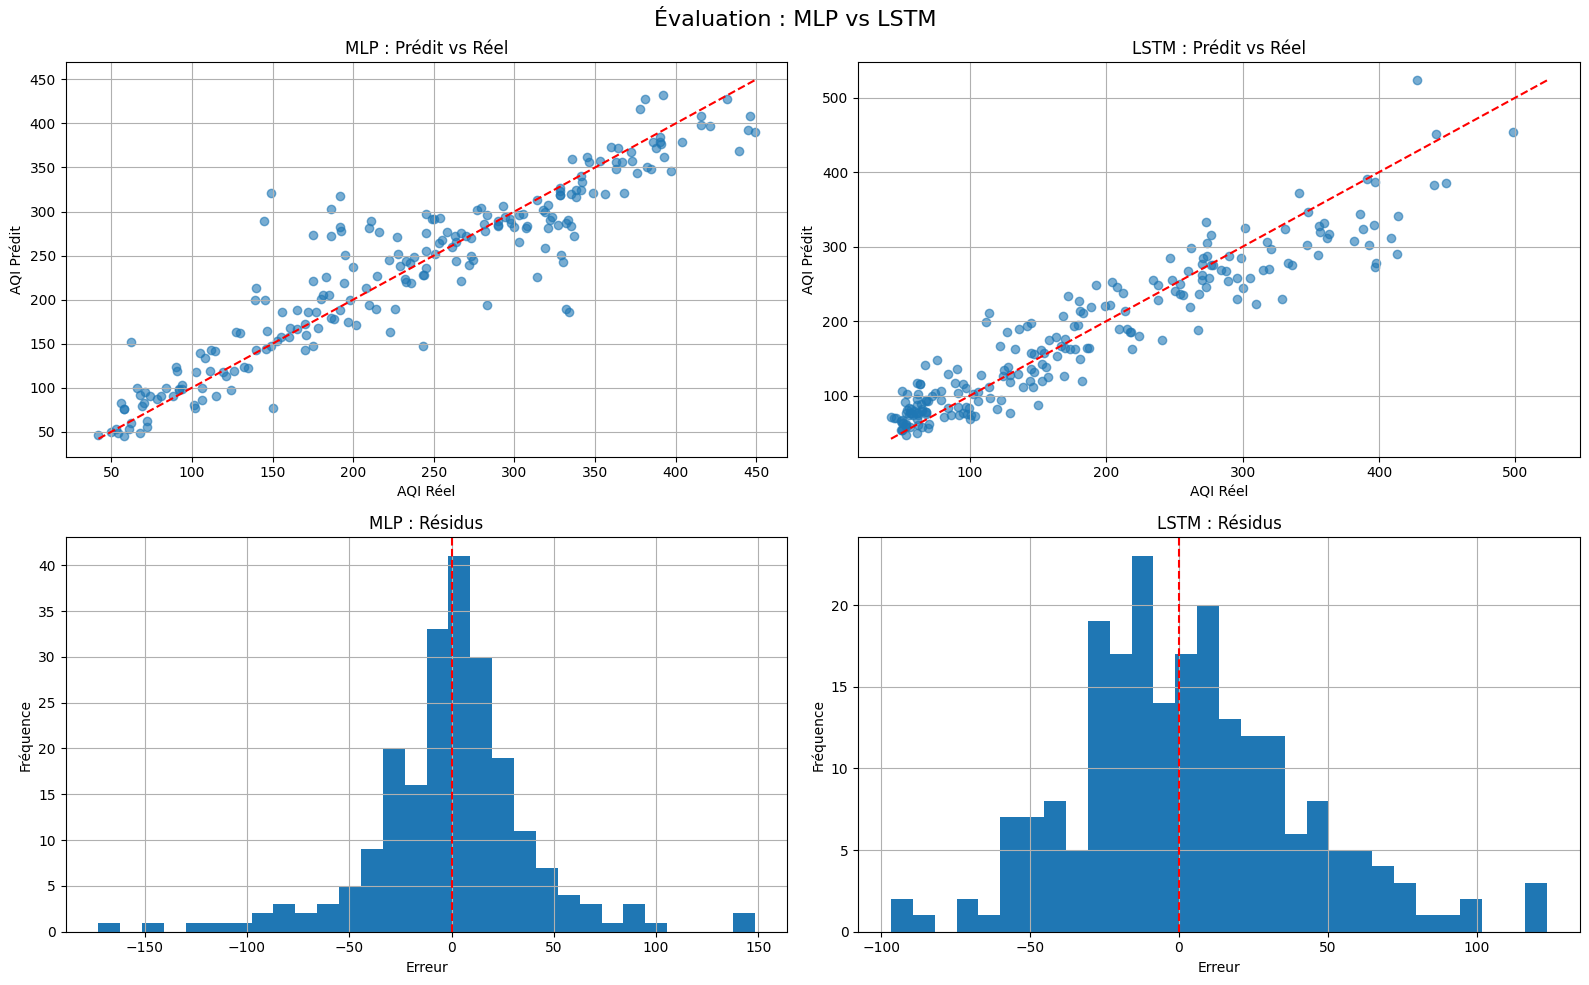

In [ ]:
#ÉVALUATION : MLP vs LSTM
fig2 = plt.figure(figsize=(16, 10))

plt.suptitle("Évaluation : MLP vs LSTM", fontsize=16)

# MLP — Prédit vs Réel
ax = fig2.add_subplot(2,2,1)

yt = mlp_te['y_true']
yp = mlp_te['y_pred']

ax.scatter(yt, yp, alpha=0.6)

lm = [
    min(yt.min(), yp.min()),
    max(yt.max(), yp.max())
]

ax.plot(lm, lm, 'r--')

ax.set_title("MLP : Prédit vs Réel")
ax.set_xlabel("AQI Réel")
ax.set_ylabel("AQI Prédit")

ax.grid(True)

# LSTM — Prédit vs Réel
ax = fig2.add_subplot(2,2,2)

yt2 = lstm_te['y_true']
yp2 = lstm_te['y_pred']

ax.scatter(yt2, yp2, alpha=0.6)

lm2 = [
    min(yt2.min(), yp2.min()),
    max(yt2.max(), yp2.max())
]

ax.plot(lm2, lm2, 'r--')

ax.set_title("LSTM : Prédit vs Réel")
ax.set_xlabel("AQI Réel")
ax.set_ylabel("AQI Prédit")

ax.grid(True)

# Résidus MLP
ax = fig2.add_subplot(2,2,3)

res_mlp = yt - yp

ax.hist(res_mlp, bins=30)

ax.axvline(0, color='red', linestyle='--')

ax.set_title("MLP : Résidus")
ax.set_xlabel("Erreur")
ax.set_ylabel("Fréquence")

ax.grid(True)

# Résidus LSTM
ax = fig2.add_subplot(2,2,4)

res_lstm = yt2 - yp2

ax.hist(res_lstm, bins=30)

ax.axvline(0, color='red', linestyle='--')

ax.set_title("LSTM : Résidus")
ax.set_xlabel("Erreur")
ax.set_ylabel("Fréquence")

ax.grid(True)

plt.tight_layout()

plt.show()

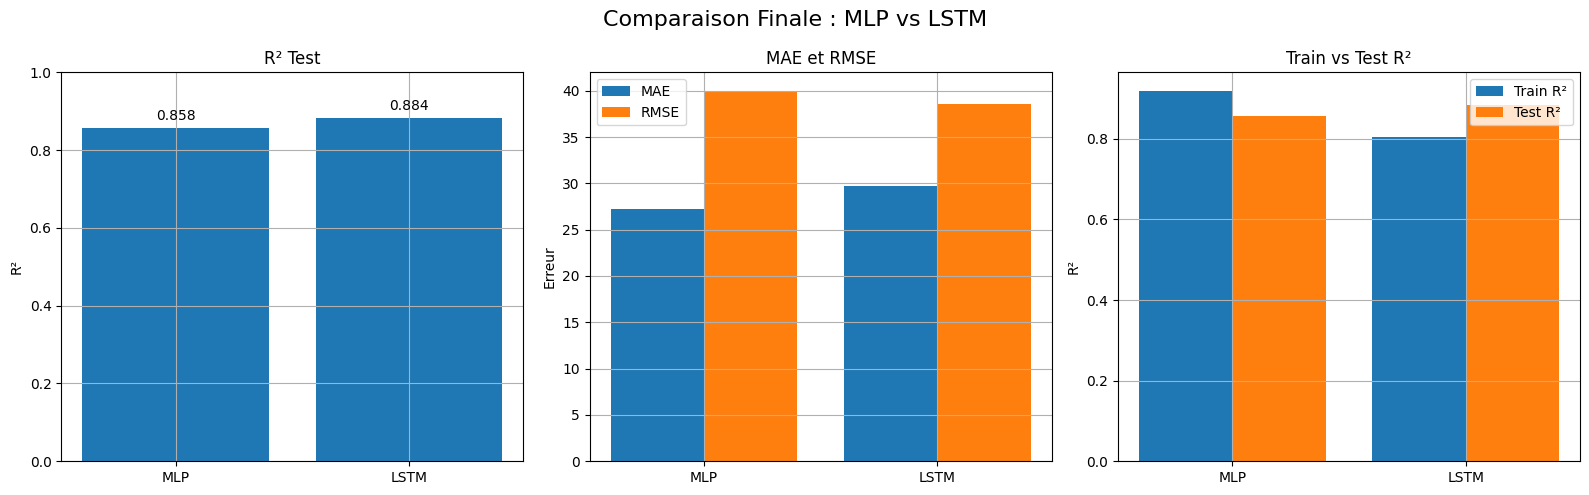

In [ ]:
# COMPARAISON  MLP vs LSTM
fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))

plt.suptitle("Comparaison Finale : MLP vs LSTM", fontsize=16)

noms = ['MLP', 'LSTM']

# Comparaison R²
ax = axes3[0]

r2_vals = [
    mlp_te['R2'],
    lstm_te['R2']
]

ax.bar(noms, r2_vals)

ax.set_title("R² Test")
ax.set_ylabel("R²")
ax.set_ylim(0, 1)

for i, v in enumerate(r2_vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center')

ax.grid(True)

# Comparaison MAE / RMSE
ax = axes3[1]

x = np.arange(2)

mae_vals = [
    mlp_te['MAE'],
    lstm_te['MAE']
]

rmse_vals = [
    mlp_te['RMSE'],
    lstm_te['RMSE']
]

ax.bar(x - 0.2, mae_vals, 0.4, label='MAE')
ax.bar(x + 0.2, rmse_vals, 0.4, label='RMSE')

ax.set_xticks(x)
ax.set_xticklabels(noms)

ax.set_title("MAE et RMSE")
ax.set_ylabel("Erreur")

ax.legend()
ax.grid(True)

# Overfitting Train/Test
ax = axes3[2]

train_r2 = [
    mlp_tr['R2'],
    lstm_tr['R2']
]

test_r2 = [
    mlp_te['R2'],
    lstm_te['R2']
]

ax.bar(x - 0.2, train_r2, 0.4, label='Train R²')
ax.bar(x + 0.2, test_r2, 0.4, label='Test R²')

ax.set_xticks(x)
ax.set_xticklabels(noms)

ax.set_title("Train vs Test R²")
ax.set_ylabel("R²")

ax.legend()
ax.grid(True)

plt.tight_layout()

plt.show()